# Part C: Python Exploratory Data Analysis (EDA)

## 1. Environment Setup & Library Imports
Importing necessary libraries for data manipulation, statistical analysis, and data visualization.



In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Dataset Loading
Loading the customer and transaction datasets using ISO-8859-1 encoding to handle non-standard characters.



In [3]:

customer_df = pd.read_csv('FinTrust_Customer_Data - FinTrust_Customer_Data.csv', encoding='ISO-8859-1')
transaction_df = pd.read_csv('FinTrust_Transaction_Data - FinTrust_Transaction_Data.csv', encoding='ISO-8859-1')

print("Datasets loaded successfully!")

Datasets loaded successfully!


## 3. Initial Data Inspection
Inspecting the first few rows of each dataset to verify data structures and column headers.

In [4]:
# Load datasets
customer_df = pd.read_csv('FinTrust_Customer_Data - FinTrust_Customer_Data.csv',encoding='ISO-8859-1')



In [5]:
# Display first 5 rows of Customer Data
print("--- Customer Data (First 5 Rows) ---")
display(customer_df.head())

# Display first 5 rows of Transaction Data
print("\n--- Transaction Data (First 5 Rows) ---")
display(transaction_df.head())

--- Customer Data (First 5 Rows) ---


,Customer_ID,Customer_Name,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status
0,FT-C00001,Ibrahim Adeyemi,56,Male,Lagos,Premium,Savings,55,84.9,500k-999k,Mobile App,Active
1,FT-C00002,Yusuf Mohammed,46,Male,Kano,Everyday,Current,79,50.7,500k-999k,Mobile App,Active
2,FT-C00003,Emeka Adeyemi,32,Female,Port Harcourt,Everyday,Savings,43,56.1,1m+,Mobile App,Active
3,FT-C00004,David Williams,60,Female,Benin City,Premium,Premium,44,54.0,500k-999k,Mobile App,Dormant
4,FT-C00005,Blessing Adeyemi,25,Male,Kaduna,Premium,Savings,68,85.1,500k-999k,Mobile App,Active



--- Transaction Data (First 5 Rows) ---


,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,Risk_Review_Flag
0,FT-T000001,FT-C01135,1/1/2026 0:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,Yes
1,FT-T000002,FT-C00428,1/1/2026 0:10,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,Yes
2,FT-T000003,FT-C00469,1/1/2026 0:21,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,No
3,FT-T000004,FT-C01015,1/1/2026 0:32,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,No
4,FT-T000005,FT-C00870,1/1/2026 0:43,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,No


In [13]:
# Dimensions and Schema for Customer Data
print(f"Customer Data Shape: {customer_df.shape[0]} rows, {customer_df.shape[1]} columns") 
print("\n--- Customer Data Information ---")
customer_df.info()



# Dimensions and Schema for Transaction Data
print(f"Transaction Data Shape: {transaction_df.shape[0]} rows, {transaction_df.shape[1]} columns")
print("\n--- Transaction Data Information ---")
transaction_df.info()

Customer Data Shape: 1500 rows, 12 columns

--- Customer Data Information ---
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               1500 non-null   str    
 1   Customer_Name             1500 non-null   str    
 2   Age                       1500 non-null   int64  
 3   Gender                    1500 non-null   str    
 4   City                      1500 non-null   str    
 5   Customer_Segment          1500 non-null   str    
 6   Account_Type              1500 non-null   str    
 7   Tenure_Months             1500 non-null   int64  
 8   Digital_Engagement_Score  1500 non-null   float64
 9   Monthly_Income_Band       1500 non-null   str    
 10  Preferred_Channel         1500 non-null   str    
 11  Account_Status            1500 non-null   str    
dtypes: float64(1), int64(2), str(9)
memory usage: 242.3

In [10]:
# Dimensions and Schema for Transaction Data
print(f"Transaction Data Shape: {transaction_df.shape[0]} rows, {transaction_df.shape[1]} columns")
print("\n--- Transaction Data Information ---")
transaction_df.info()

Transaction Data Shape: 12000 rows, 11 columns

--- Transaction Data Information ---
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Transaction_ID             12000 non-null  str    
 1   Customer_ID                12000 non-null  str    
 2   Transaction_DateTime       12000 non-null  str    
 3   Transaction_Type           12000 non-null  str    
 4   Amount_NGN                 12000 non-null  float64
 5   Channel                    12000 non-null  str    
 6   Device_Type                11904 non-null  str    
 7   Location                   11904 non-null  str    
 8   International_Transaction  12000 non-null  str    
 9   Transaction_Status         12000 non-null  str    
 10  Risk_Review_Flag           12000 non-null  str    
dtypes: float64(1), str(10)
memory usage: 1.9 MB


## 4. Data Preprocessing & Merging
Converting datetime columns to standard formats, creating time-period features, and merging customer details into the transaction dataset.

In [14]:
# Clean datetime column
transaction_df['Transaction_DateTime'] = pd.to_datetime(
    transaction_df['Transaction_DateTime'], format='%m/%d/%Y %H:%M', errors='coerce'
)
transaction_df['Year_Month'] = transaction_df['Transaction_DateTime'].dt.to_period('M')

# Merge datasets on Customer_ID
merged_df = pd.merge(transaction_df, customer_df, on='Customer_ID', how='inner')

print(f"Merged Dataset Shape: {merged_df.shape[0]} rows, {merged_df.shape[1]} columns")
merged_df.head()

Merged Dataset Shape: 12000 rows, 23 columns


,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,...,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status
0,FT-T000001,FT-C01135,2026-01-01 00:00:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,...,44,Female,Ibadan,Everyday,Current,50,42.9,500k-999k,Mobile App,Active
1,FT-T000002,FT-C00428,2026-01-01 00:10:00,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,...,23,Male,Lagos,Everyday,Current,50,95.0,Below 100k,Web,Active
2,FT-T000003,FT-C00469,2026-01-01 00:21:00,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,...,39,Female,Kaduna,Everyday,Current,53,64.4,100k-249k,Mobile App,Active
3,FT-T000004,FT-C01015,2026-01-01 00:32:00,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,...,50,Female,Lagos,Everyday,Current,19,61.7,100k-249k,Mobile App,Active
4,FT-T000005,FT-C00870,2026-01-01 00:43:00,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,...,58,Female,Kano,Everyday,Savings,8,76.5,100k-249k,Mobile App,Active


## 5. Visualization Setup
Setting global styling parameters for Seaborn and Matplotlib figures.

In [3]:
# Set global aesthetic style
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'


print("Visual style configured!")

Visual style configured!


### Visualization 1: Total Transaction Volume by Customer Segment

* **What does the visual show?** A bar chart comparing total aggregated transaction volume (NGN) across customer segments (Everyday, SME, Student, Premium).
* **Why is it important?** Identifies primary revenue drivers versus transaction frequency across customer groups.
* **Business Insight:** While Everyday accounts account for high transaction frequency, SME and Premium segments drive substantially higher average monetary value per account.

C:\Users\HP\AppData\Local\Temp\ipykernel_15208\2384358835.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


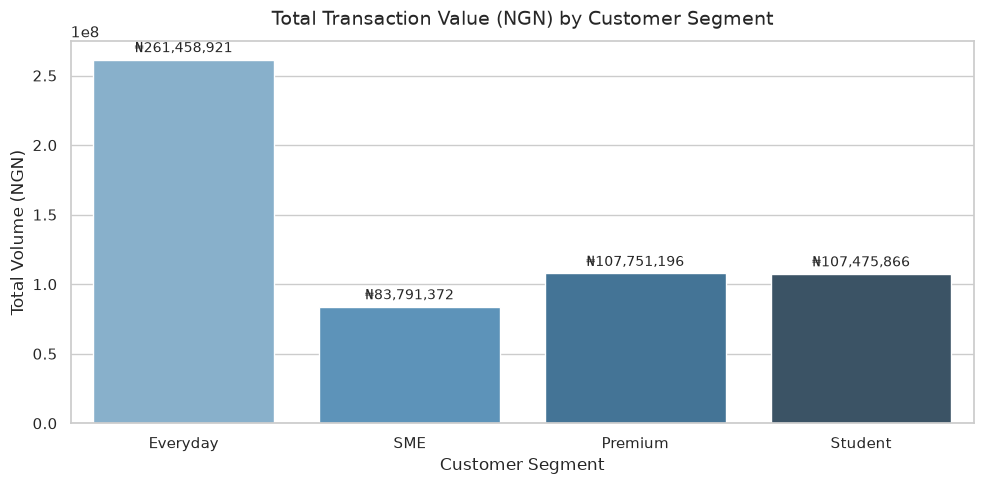

In [19]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=merged_df, 
    x='Customer_Segment', 
    y='Amount_NGN', 
    estimator=sum, 
    errorbar=None, 
    palette='Blues_d'
)
plt.title('Total Transaction Value (NGN) by Customer Segment', fontsize=14, pad=12)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Total Volume (NGN)', fontsize=12)

# Annotate bars with formatted values
for p in ax.patches:
    ax.annotate(f'₦{p.get_height():,.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, xytext=(0, 3), 
                textcoords='offset points')


plt.tight_layout()
plt.show()

### Visualization 2: Transaction Status Breakdown by Delivery Channel

* **What does the visual show?** A 100% stacked bar chart depicting the percentage breakdown of Successful, Failed, and Pending transactions across all delivery channels.
* **Why is it important?** Pinpoints technical failure rates and delivery reliability across interaction platforms.
* **Business Insight:** Successful transactions exceed 90% across all channels, but Web and ATM channels exhibit elevated failure rates requiring infrastructure optimization.

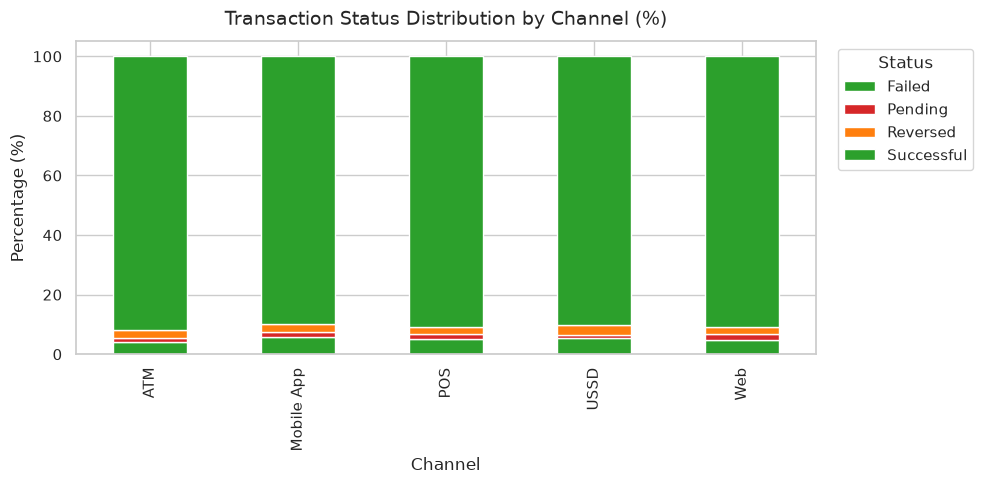

In [29]:
channel_status = pd.crosstab(merged_df['Channel'], merged_df['Transaction_Status'], normalize='index') * 100

ax = channel_status.plot(kind='bar', stacked=True, color=['#2ca02c', '#d62728', '#ff7f0e'], figsize=(10, 5))
plt.title('Transaction Status Distribution by Channel (%)', fontsize=14, pad=12)
plt.xlabel('Channel', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Visualization 3: Distribution of Risk-Flagged Transactions by Device Type

* **What does the visual show?** A grouped bar chart displaying the frequency of risk-flagged (`Yes` vs `No`) transactions segmented by device operating system.
* **Why is it important?** Pinpoints security vulnerability vectors and device-level exposure.
* **Business Insight:** Android devices account for the highest volume of risk-flagged transactions. Targeted step-up authentication on high-value Android transactions can mitigate potential fraud.

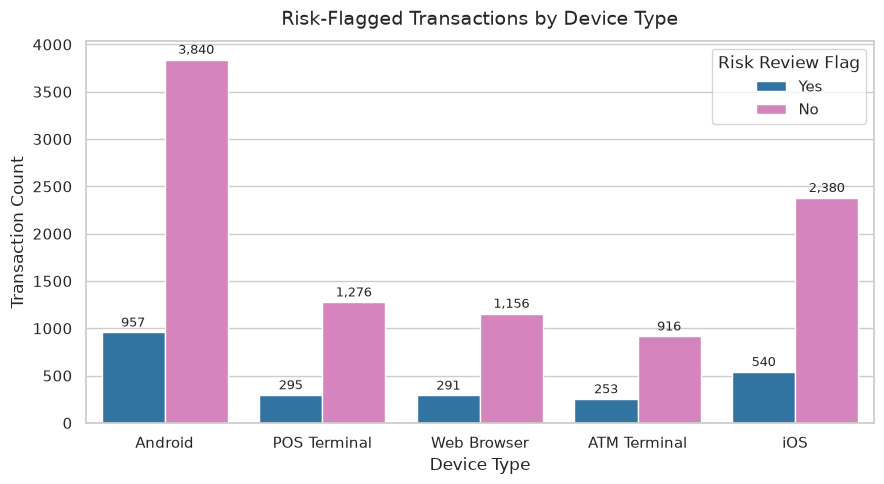

In [22]:
plt.figure(figsize=(9, 5))
ax = sns.countplot(
    data=merged_df, 
    x='Device_Type', 
    hue='Risk_Review_Flag', 
    palette=['#1f77b4', '#e377c2']
)
plt.title('Risk-Flagged Transactions by Device Type', fontsize=14, pad=12)
plt.xlabel('Device Type', fontsize=12)
plt.ylabel('Transaction Count', fontsize=12)
plt.legend(title='Risk Review Flag', loc='upper right')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:,.0f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', fontsize=9, xytext=(0, 2), 
                    textcoords='offset points')

plt.tight_layout()
plt.show()

### Visualization 4: Monthly Volume and Average Transaction Value Trend

* **What does the visual show?** A dual-axis line plot demonstrating monthly transaction volume alongside average transaction values across Q1 2026.
* **Why is it important?** Tracks growth momentum and customer adoption progression over time.
* **Business Insight:** Overall volume and average transaction size peaked in March 2026, demonstrating expanding customer activity and trust over time.

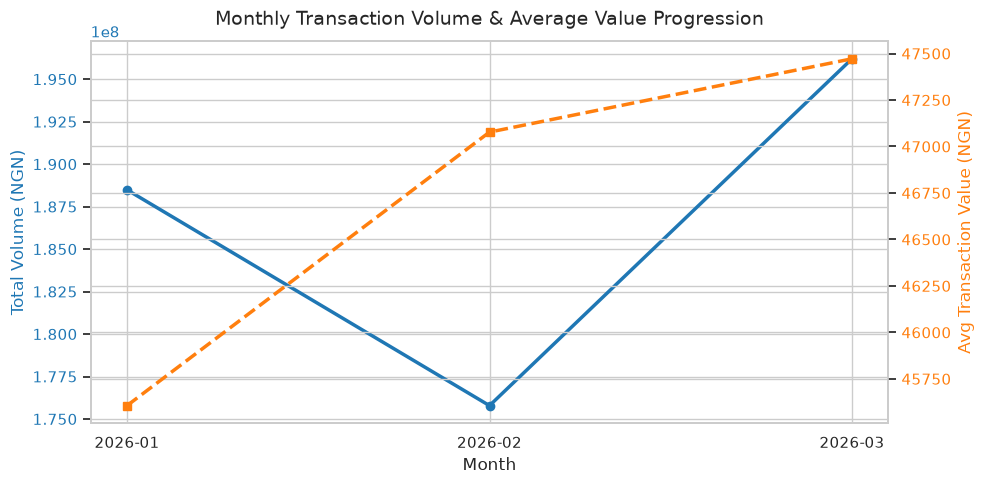

In [23]:
monthly_summary = merged_df.groupby('Year_Month').agg(
    Total_Volume=('Amount_NGN', 'sum'),
    Avg_Amount=('Amount_NGN', 'mean')
).reset_index()

monthly_summary['Year_Month'] = monthly_summary['Year_Month'].astype(str)

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Total Volume (NGN)', color=color, fontsize=12)
ax1.plot(monthly_summary['Year_Month'], monthly_summary['Total_Volume'], color=color, marker='o', linewidth=2.5)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Avg Transaction Value (NGN)', color=color, fontsize=12)
ax2.plot(monthly_summary['Year_Month'], monthly_summary['Avg_Amount'], color=color, marker='s', linestyle='--', linewidth=2.5)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Monthly Transaction Volume & Average Value Progression', fontsize=14, pad=12)
fig.tight_layout()
plt.show()